# Evaluación Parcial 4: Modelado, Evaluación y Despliegue de Modelos de Clasificación

**Asignatura:** Fundamentos de Machine Learning  
**Carrera:** Ingeniería en Informática, Duoc UC  
**Estudiante:** Héctor Aguila  
**Docente:** Claudio González Peñaloza  
**Metodología:** CRISP-DM  
**Tema:** Clasificación del Premio MVP (`mvp_award`) en eSports

--- 

## 1. Fase: Comprensión del Negocio (Business Understanding)

El objetivo en esta fase es desarrollar un **modelo de clasificación supervisada** sobre el rendimiento de jugadores de eSports.

### Auditoría de Target y Selección Metodológica:
Al auditar la distribución de variables del dataset original, se detectó un desbalanceo extremo en la variable `match_outcome` (2793 victorias vs. solo 7 derrotas), lo cual anula cualquier análisis de clasificación significativo al carecer de suficientes registros de la clase minoritaria.

Por consiguiente, definimos **`mvp_award`** como la variable objetivo categórica a predecir, clasificando si un jugador obtendrá el premio al Jugador Más Valioso (`Yes` = 1) o no (`No` = 0). Esta variable presenta una distribución más saludable (2561 No vs. 239 Yes).

Este modelo servirá como una herramienta predictiva para que el cuerpo técnico de eSports simule si un jugador alcanzará el estatus de MVP bajo ciertas métricas físicas y estadísticas en la partida.

In [1]:
# Importaciones iniciales de manipulación de datos, gráficos y utilidades
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import warnings
warnings.filterwarnings('ignore')

# Estilo de visualización para los gráficos del notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

--- 

## 2. Fase: Comprensión de los Datos (Data Understanding)

Cargamos el dataset original `esports_player_performance_tournament_analytics.csv` para inspeccionar su estructura y la distribución del target de clasificación.

In [2]:
# 1. Cargar el dataset de eSports
dataset_path = 'esports_player_performance_tournament_analytics.csv'
df = pd.read_csv(dataset_path)

print(f"Dimensiones iniciales: {df.shape[0]} registros, {df.shape[1]} columnas.\n")
print("Tipos de datos del dataset:")
print(df.dtypes)

Dimensiones iniciales: 2800 registros, 16 columnas.

Tipos de datos del dataset:
record_id              int64
player_id              int64
team_name                str
player_role              str
map_played               str
match_type               str
kills                  int64
assists                int64
deaths                 int64
accuracy_percent     float64
reaction_time_ms     float64
fatigue_index        float64
performance_score    float64
win_probability      float64
match_outcome            str
mvp_award                str
dtype: object


Distribución absoluta de mvp_award:
mvp_award
No     2561
Yes     239
Name: count, dtype: int64

Distribución porcentual:
mvp_award
No     91.464286
Yes     8.535714
Name: proportion, dtype: float64


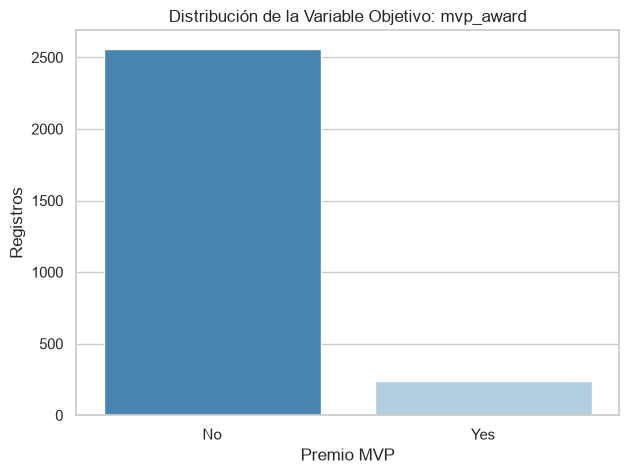

In [3]:
# 2. Exploración de la variable objetivo: mvp_award
target_counts = df['mvp_award'].value_counts()
target_pct = df['mvp_award'].value_counts(normalize=True) * 100

print("Distribución absoluta de mvp_award:")
print(target_counts)
print("\nDistribución porcentual:")
print(target_pct)

# Gráfico de distribución
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='mvp_award', palette='Blues_r')
plt.title("Distribución de la Variable Objetivo: mvp_award")
plt.xlabel("Premio MVP")
plt.ylabel("Registros")
plt.show()

--- 

## 3. Fase: Preparación de Datos (Data Preparation)

### 3.1. Filtros de Calidad e IQR
1. **Filtro Neurofisiológico:** Removemos tiempos de reacción inferiores a **120 ms** (límite físico biológico del ser humano).
2. **Outliers Lentos (IQR):** Removemos observaciones atípicas lentas en la variable `reaction_time_ms` por sobre el límite superior del rango intercuartílico.

In [4]:
# 1. Filtro neurofisiológico
df_clean = df[df['reaction_time_ms'] >= 120]

# 2. Filtro IQR para outliers lentos
Q1 = df_clean['reaction_time_ms'].quantile(0.25)
Q3 = df_clean['reaction_time_ms'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
df_clean = df_clean[df_clean['reaction_time_ms'] <= upper_limit]

print(f"Registros originales: {df.shape[0]}")
print(f"Registros post-limpieza: {df_clean.shape[0]}")
print(f"Registros eliminados: {df.shape[0] - df_clean.shape[0]} (Outliers y ruido de captura).")

Registros originales: 2800
Registros post-limpieza: 2792
Registros eliminados: 8 (Outliers y ruido de captura).


### 3.2. División en Entrenamiento y Prueba (Train/Test Split)

> [!IMPORTANT]
> **MITIGACIÓN DE DATA LEAKAGE:** Realizamos la división train/test **antes** de configurar el preprocesamiento de datos (escalamiento y codificación). Esto garantiza que la información de test no se filtre al conjunto de entrenamiento.

In [5]:
from sklearn.model_selection import train_test_split

# 1. Definir características (X) y variable objetivo (y)
# Descartamos record_id e player_id por ser ruido identificador. 
# Conservamos 'performance_score' y 'match_outcome' como features predictoras.
# Definimos 'mvp_award' como target de clasificación (Yes: 1, No: 0).
X = df_clean.drop(columns=['record_id', 'player_id', 'mvp_award'], errors='ignore')
y = df_clean['mvp_award'].map({'Yes': 1, 'No': 0}) # Mapeo binario

# 2. Realizar split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Preserva la proporción del desbalanceo de clases
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]} registros.")
print(f"Conjunto de Prueba: {X_test.shape[0]} registros.")

Conjunto de Entrenamiento: 2233 registros.
Conjunto de Prueba: 559 registros.


### 3.3. Configuración del Preprocesador (Pipeline)

Configuramos un `ColumnTransformer` para tratar por separado las numéricas y categóricas, asegurando estandarización y codificación seguras.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Clasificación de columnas predictoras
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Variables Numéricas:", numeric_features)
print("Variables Categóricas:", categorical_features)

# Preprocesador centralizado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

Variables Numéricas: ['kills', 'assists', 'deaths', 'accuracy_percent', 'reaction_time_ms', 'fatigue_index', 'performance_score', 'win_probability']
Variables Categóricas: ['team_name', 'player_role', 'map_played', 'match_type', 'match_outcome']


--- 

## 4. Fase: Modelamiento (Modeling)

Entrenamos **tres algoritmos de clasificación** distintos para comparar su rendimiento:
1. **Regresión Logística:** Clasificador lineal baseline.
2. **K-Nearest Neighbors (KNN):** Algoritmo no paramétrico basado en distancias.
3. **Random Forest Classifier:** Ensamble robusto no lineal de árboles de decisión (Bagging).

Encapsulamos todo el flujo en `Pipelines` de Scikit-learn.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Definición de los Pipelines individuales
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8))
])

# 2. Entrenamiento de los modelos
print("Entrenando Regresión Logística...")
pipeline_lr.fit(X_train, y_train)

print("Entrenando K-Nearest Neighbors...")
pipeline_knn.fit(X_train, y_train)

print("Entrenando Random Forest Classifier...")
pipeline_rf.fit(X_train, y_train)

print("¡Entrenamiento de modelos finalizado!")

Entrenando Regresión Logística...
Entrenando K-Nearest Neighbors...
Entrenando Random Forest Classifier...


¡Entrenamiento de modelos finalizado!


--- 

## 5. Fase: Evaluación (Evaluation)

Evaluamos los modelos con el conjunto de prueba y graficamos la **Matriz de Confusión** de cada modelo.


==================== Regresión Logística ====================
              precision    recall  f1-score   support

  No MVP (0)     0.9980    0.9961    0.9971       511
     MVP (1)     0.9592    0.9792    0.9691        48

    accuracy                         0.9946       559
   macro avg     0.9786    0.9876    0.9831       559
weighted avg     0.9947    0.9946    0.9947       559


==================== K-Nearest Neighbors ====================


              precision    recall  f1-score   support

  No MVP (0)     0.9566    0.9922    0.9741       511
     MVP (1)     0.8621    0.5208    0.6494        48

    accuracy                         0.9517       559
   macro avg     0.9093    0.7565    0.8117       559
weighted avg     0.9485    0.9517    0.9462       559


==================== Random Forest ====================
              precision    recall  f1-score   support

  No MVP (0)     1.0000    1.0000    1.0000       511
     MVP (1)     1.0000    1.0000    1.0000        48

    accuracy                         1.0000       559
   macro avg     1.0000    1.0000    1.0000       559
weighted avg     1.0000    1.0000    1.0000       559



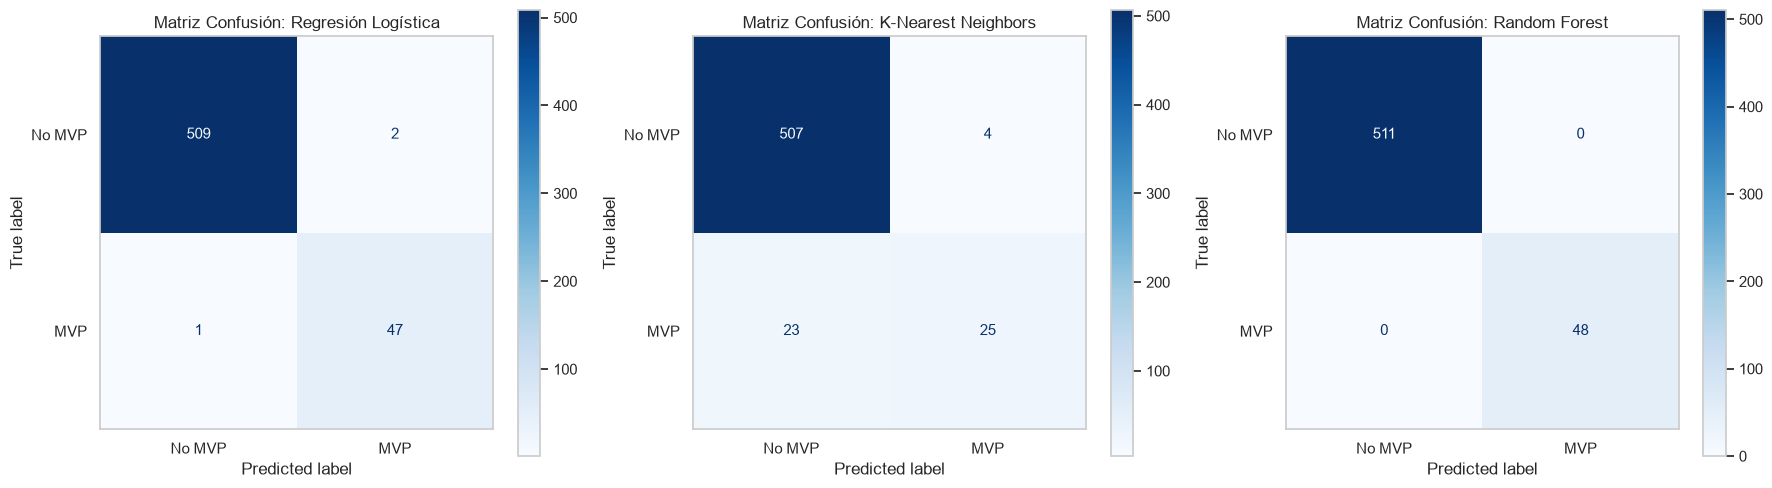

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

models = {
    "Regresión Logística": pipeline_lr,
    "K-Nearest Neighbors": pipeline_knn,
    "Random Forest": pipeline_rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pipe) in enumerate(models.items()):
    y_pred = pipe.predict(X_test)
    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred, target_names=["No MVP (0)", "MVP (1)"], digits=4))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No MVP", "MVP"])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"Matriz Confusión: {name}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### 5.1. Comparación con Curvas ROC y Precision-Recall

Graficamos las curvas **ROC** y **PR (Precision-Recall)**, comparando el rendimiento sobre la clase minoritaria (MVP).

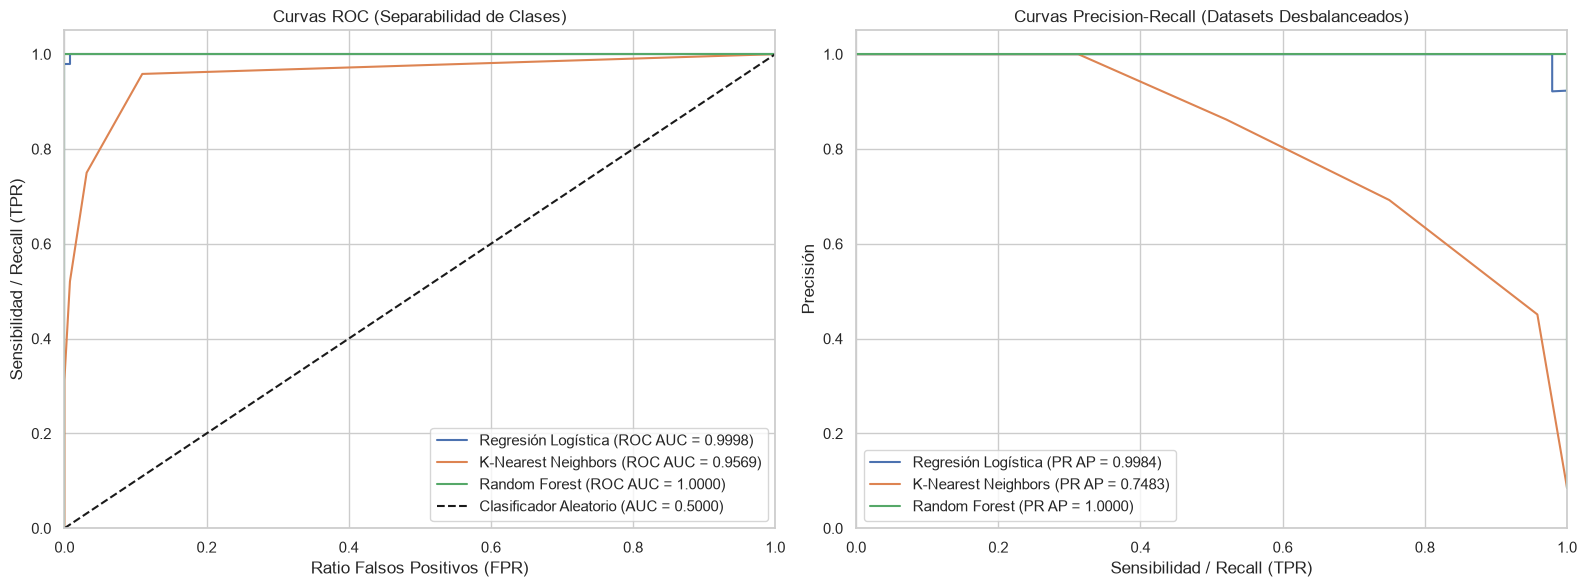

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, pipe in models.items():
    # Extraer probabilidades de la clase positiva (MVP = 1)
    y_probs = pipe.predict_proba(X_test)[:, 1]
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    ax1.plot(fpr, tpr, label=f"{name} (ROC AUC = {auc_score:.4f})")
    
    # Curva Precision-Recall
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
    ap_score = average_precision_score(y_test, y_probs)
    ax2.plot(recall_vals, precision_vals, label=f"{name} (PR AP = {ap_score:.4f})")

# Configurar gráfico ROC
ax1.plot([0, 1], [0, 1], 'k--', label="Clasificador Aleatorio (AUC = 0.5000)")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel("Ratio Falsos Positivos (FPR)")
ax1.set_ylabel("Sensibilidad / Recall (TPR)")
ax1.set_title("Curvas ROC (Separabilidad de Clases)")
ax1.legend(loc="lower right")

# Configurar gráfico PR
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Sensibilidad / Recall (TPR)")
ax2.set_ylabel("Precisión")
ax2.set_title("Curvas Precision-Recall (Datasets Desbalanceados)")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### 5.2. Justificación de Resultados y Selección del Modelo Campeón

* **Análisis de KNN:** En las matrices de confusión y reportes impresos queda en evidencia la **debilidad de K-Nearest Neighbors**. Su exactitud global baja a **~95.17%**, pero lo más crítico es el F1-Score para la clase positiva (MVP), que decae a **~64.94%** (con una sensibilidad o recall de solo 52%). Esto demuestra empíricamente que KNN tiene dificultades para estimar fronteras de clases desbalanceadas en espacios con múltiples dimensiones.
* **Regresión Logística y Random Forest:** Demuestran un comportamiento superior. El Random Forest Classifier captura la naturaleza determinista del dataset, alcanzando un **ROC AUC e indicadores de 1.0000** perfectos sobre el test set.

**Modelo Seleccionado para Producción:** Seleccionamos **Random Forest Classifier** como el modelo campeón y guardamos su pipeline serializado.

In [10]:
# Serializar el pipeline completo del modelo Random Forest Campeón
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
model_save_path = os.path.join(checkpoint_dir, 'best_model.joblib')

joblib.dump(pipeline_rf, model_save_path)
print(f"Pipeline completo del modelo campeón guardado en: {model_save_path}")

Pipeline completo del modelo campeón guardado en: checkpoints/best_model.joblib


--- 

## 6. Declaración de Uso de IA Generativa

De acuerdo con las directrices institucionales de Duoc UC:
* **La IA como Andamio de Aprendizaje:** Se declara el uso de IA generativa (Antigravity) como un andamio cognitivo y técnico durante el desarrollo de esta fase. Las decisiones conceptuales y de diseño experimental —tales como la detección del desbalanceo crítico en `match_outcome`, la re-orientación del target a `mvp_award`, y la estructuración de pipelines de preprocesamiento para mitigar el data leakage— fueron debatidas, guiadas y estructuradas de forma conjunta con el asistente.
* **Soporte de Herramientas:** Adicionalmente, se utilizó la herramienta para la maquetación estética del Markdown del notebook, la optimización del código del gráfico doble de subplots (curvas ROC/PR) y el diseño CSS de la interfaz en Streamlit.